In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!git clone https://github.com/razorx89/roco-dataset.git

Cloning into 'roco-dataset'...
remote: Enumerating objects: 114, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 114 (delta 7), reused 20 (delta 7), pack-reused 91 (from 1)
Receiving objects: 100% (114/114), 13.01 MiB | 13.36 MiB/s, done.
Resolving deltas: 100% (31/31), done.


In [3]:
!python3 /content/roco-dataset/scripts/fetch.py


Streaming output truncated to the last 5000 lines.
89.311% | 41617/46598 | PMC4432449
89.313% | 41618/46598 | PMC1978243
89.315% | 41619/46598 | PMC3953627
89.317% | 41620/46598 | PMC4675004
89.319% | 41621/46598 | PMC4460548
89.321% | 41622/46598 | PMC5502573
89.324% | 41623/46598 | PMC3290114
89.326% | 41624/46598 | PMC4435852
89.328% | 41625/46598 | PMC2740835
89.330% | 41626/46598 | PMC2253542
89.332% | 41627/46598 | PMC4055357
89.334% | 41628/46598 | PMC4564506
89.336% | 41629/46598 | PMC3954297
89.339% | 41630/46598 | PMC1368977
89.341% | 41631/46598 | PMC3015802
89.343% | 41632/46598 | PMC4143510
89.345% | 41633/46598 | PMC3627160
89.347% | 41634/46598 | PMC2841377
89.349% | 41635/46598 | PMC4152832
89.351% | 41636/46598 | PMC2629172
89.354% | 41637/46598 | PMC3340973
89.356% | 41638/46598 | PMC5133587
89.358% | 41639/46598 | PMC4379335
89.360% | 41640/46598 | PMC5721486
89.362% | 41641/46598 | PMC4224691
89.364% | 41642/46598 | PMC4897456
89.366% | 41643/46598 | PMC5739534
89.3

In [4]:
import shutil

# Specify the source path in Colab and the destination in Google Drive
source_path = '/content/roco-dataset'
destination_path = '/content/drive/MyDrive/ROCO/'

# Move the file or folder
shutil.move(source_path, destination_path)


'/content/drive/MyDrive/ROCO/'

In [5]:
!zip -r roco.zip . - i /content/drive/MyDrive/ROCO_dataset/

Streaming output truncated to the last 5000 lines.
  adding: drive/MyDrive/ROCO/data/validation/radiology/images/ROCO_02438.jpg (deflated 0%)
  adding: drive/MyDrive/ROCO/data/validation/radiology/images/ROCO_81509.jpg (deflated 0%)
  adding: drive/MyDrive/ROCO/data/validation/radiology/images/ROCO_03287.jpg (deflated 1%)
  adding: drive/MyDrive/ROCO/data/validation/radiology/images/ROCO_49944.jpg (deflated 1%)
  adding: drive/MyDrive/ROCO/data/validation/radiology/images/ROCO_54567.jpg (deflated 0%)
  adding: drive/MyDrive/ROCO/data/validation/radiology/images/ROCO_54370.jpg (deflated 4%)
  adding: drive/MyDrive/ROCO/data/validation/radiology/images/ROCO_45105.jpg (deflated 24%)
  adding: drive/MyDrive/ROCO/data/validation/radiology/images/ROCO_21195.jpg (deflated 67%)
  adding: drive/MyDrive/ROCO/data/validation/radiology/images/ROCO_04407.jpg (deflated 25%)
  adding: drive/MyDrive/ROCO/data/validation/radiology/images/ROCO_59709.jpg (deflated 2%)
  adding: drive/MyDrive/ROCO/data/va

In [8]:

import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt
import re
import torch
import torch.nn as nn
import torch.optim as optim
#from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms as transforms

In [9]:
df = pd.read_table('/content/drive/MyDrive/ROCO/data/train/radiology/captions.txt',header=None,names = ['image_id','caption'])
df

,image_id,caption
0,ROCO_00002,Computed tomography scan in axial view showin...
1,ROCO_00003,Bacterial contamination occurred after comple...
2,ROCO_00004,The patient had residual paralysis of the han...
3,ROCO_00005,Panoramic radiograph after immediate loading.
4,ROCO_00007,Plain abdomen x-ray: Multiple air levels at t...
...,...,...
65445,ROCO_81819,Initial CT abdomen with contrast showing a di...
65446,ROCO_81820,44-year-old male patient after surgical amput...
65447,ROCO_81821,Primary pulmonary tuberculosis in 18-year-old...
65448,ROCO_81822,"MRI brain with gadolinium, coronal view, show..."


In [10]:
df['caption'].describe()

,caption
count,65450
unique,64772
top,Initial panoramic radiograph.
freq,19


In [12]:
df['caption'].tail(5)

,caption
65445,Initial CT abdomen with contrast showing a di...
65446,44-year-old male patient after surgical amput...
65447,Primary pulmonary tuberculosis in 18-year-old...
65448,"MRI brain with gadolinium, coronal view, show..."
65449,Contrast-enhanced 3D MRL image of the lower e...


In [13]:
df.columns

Index(['image_id', 'caption'], dtype='object')

In [14]:
print(df.isnull)

<bound method DataFrame.isnull of          image_id                                            caption
0      ROCO_00002   Computed tomography scan in axial view showin...
1      ROCO_00003   Bacterial contamination occurred after comple...
2      ROCO_00004   The patient had residual paralysis of the han...
3      ROCO_00005      Panoramic radiograph after immediate loading.
4      ROCO_00007   Plain abdomen x-ray: Multiple air levels at t...
...           ...                                                ...
65445  ROCO_81819   Initial CT abdomen with contrast showing a di...
65446  ROCO_81820   44-year-old male patient after surgical amput...
65447  ROCO_81821   Primary pulmonary tuberculosis in 18-year-old...
65448  ROCO_81822   MRI brain with gadolinium, coronal view, show...
65449  ROCO_81823   Contrast-enhanced 3D MRL image of the lower e...

[65450 rows x 2 columns]>


In [15]:
df['caption'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 65450 entries, 0 to 65449
Series name: caption
Non-Null Count  Dtype 
--------------  ----- 
65450 non-null  object
dtypes: object(1)
memory usage: 511.5+ KB


In [16]:
df['caption'].value_counts()

,count
caption,
Initial panoramic radiograph.,19
Preoperative radiograph,15
Postoperative radiograph,13
Chest X-ray,11
Final panoramic radiograph.,11
...,...
Computed tomographic scan of the abdomen and pelvis showed a foreign body invading the posterior wall of the uterus and entering the colon.,1
Computed tomography scan at the level of the lateral ventricles. There is a thin layer of acute subdural hematoma identified on the left with a minimal midline shift (arrow). A = anterior; P = posterior; L = left; R = right.,1
Magnetic resonance imaging of the mass,1


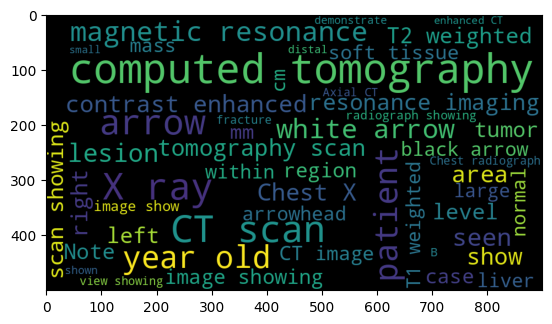

In [17]:
from wordcloud import WordCloud
caption_text=' '.join(df['caption'].astype(str))
wordcloud=WordCloud(width=900,height=500,max_words=50).generate(caption_text)
plt.imshow(wordcloud)

In [18]:

dlink_url='/content/drive/MyDrive/ROCO/data/test/non-radiology/dlinks.txt'
dlink = pd.read_table(dlink_url,header = None,names=['image_id','dlink','image'])
dlink

,image_id,dlink,image
0,ROCO_81827,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,1678-7757-jaos-14-02-0117-gf05.jpg
1,ROCO_81835,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,0036-4665-rimtsp-56-01-00092-gf01.jpg
2,ROCO_81851,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,opth-9-169Fig1.jpg
3,ROCO_81853,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,10561_2011_9244_Fig1_HTML.jpg
4,ROCO_81857,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,jsls-1-1-83-g02.jpg
...,...,...,...
607,ROCO_87910,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,10-7162-s-1809-97772012000400015-i160415-2.jpg
608,ROCO_87912,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,alm-35-657-g001.jpg
609,ROCO_87919,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,BMRI2015-475392.002.jpg
610,ROCO_87932,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,1471-2202-14-S1-P193-1.jpg


In [19]:
import pandas as pd
import os

# Load captions data
textdata = pd.read_table('/content/drive/MyDrive/ROCO/data/train/radiology/captions.txt', header=None, names=['Image_ID', 'caption'])

# Create a DataFrame for image files
image_files = r"/content/drive/MyDrive/ROCO/data/train/radiology/images"
image_files_list = os.listdir(image_files)
image_files_df = pd.DataFrame(image_files_list, columns=['image_file'])

# Add an index column to both DataFrames to ensure correct alignment
textdata['index'] = textdata.index
image_files_df['index'] = image_files_df.index

# Merge based on the index column
merged_df = pd.merge(image_files_df, textdata, on='index', how='inner')

# Reorder columns to display image_file first
merged_df = merged_df[['image_file', 'caption']]

# Display the result (ensure both columns are properly aligned)
print(merged_df.head(10))  # Show the first 10 rows, adjust as necessary


       image_file                                            caption
0  ROCO_28626.jpg   Computed tomography scan in axial view showin...
1  ROCO_36223.jpg   Bacterial contamination occurred after comple...
2  ROCO_37113.jpg   The patient had residual paralysis of the han...
3  ROCO_70664.jpg      Panoramic radiograph after immediate loading.
4  ROCO_31442.jpg   Plain abdomen x-ray: Multiple air levels at t...
5  ROCO_63329.jpg   A 3-year-old child with visual difficulties. ...
6  ROCO_42992.jpg   Showing the subtrochanteric fracture in the p...
7  ROCO_49359.jpg   Post orthodontic treatment. Root canal therap...
8  ROCO_38427.jpg   Two sequential thrombi in the distal segment ...
9  ROCO_77036.jpg   An example of MRI image that takes advantage ...


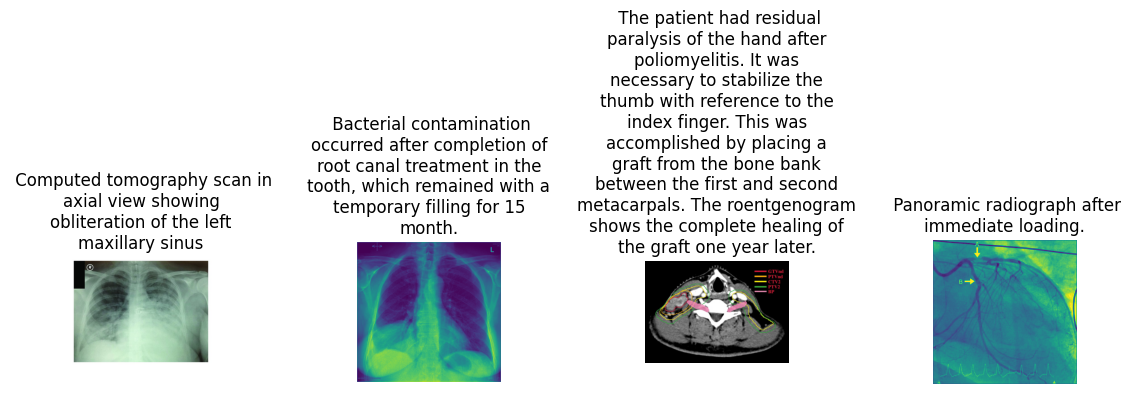

In [23]:
img ="/content/drive/MyDrive/ROCO/data/train/radiology/images"
list1 = []
if os.path.exists(img):
    for file in os.listdir(img):
        list1.append(file)
else:
    print(f"The path {img} does not exist.")
len(list1)
import textwrap

file_names1 = os.listdir(img)
wrap_width = 30

fig, axs = plt.subplots(1,4, figsize=(13, 15))

plt.subplots_adjust(wspace = 1,hspace=1)
axs = axs.flatten()
for i in range(4):
    file_path = os.path.join(img, list1[i])
    image = Image.open(file_path)
    caption = df["caption"][i]
    wrapped_caption = "\n".join(textwrap.wrap(caption, wrap_width))
    axs[i].imshow(image)
    axs[i].set_title(wrapped_caption)
    axs[i].axis('off')

plt.show()

In [24]:
data_dir = '/content/drive/MyDrive/ROCO/data'

# Initialize an empty list to store the data
data = []

# Iterate through each split (train, test, validation)
for split in ['train', 'test', 'validation']:
    split_dir = os.path.join(data_dir, split)

    # Iterate through each category (radiology, non-radiology)
    for category in ['radiology', 'non-radiology']:
        category_dir = os.path.join(split_dir, category)
        captions_file = os.path.join(category_dir, 'captions.txt')

        # Read captions.txt if it exists
        if os.path.exists(captions_file):
            with open(captions_file, 'r') as file:
                # Read each line in the file as a caption
                for line in (file):
                    caption = line[12:].strip()
                    id = line[:12]
                    label = 'radiology' if category == 'radiology' else 'non-radiology'
                    # Append the caption, label, and split type to the data list
                    data.append([id,caption, label, split])

# Create a DataFrame with the collected data
data = pd.DataFrame(data, columns=['image_id','Caption', 'Label', 'Split'])

data

,image_id,Caption,Label,Split
0,ROCO_00002\t,Computed tomography scan in axial view showing...,radiology,train
1,ROCO_00003\t,Bacterial contamination occurred after complet...,radiology,train
2,ROCO_00004\t,The patient had residual paralysis of the hand...,radiology,train
3,ROCO_00005\t,Panoramic radiograph after immediate loading.,radiology,train
4,ROCO_00007\t,Plain abdomen x-ray: Multiple air levels at th...,radiology,train
...,...,...,...,...
87922,ROCO_87894\t,Scanning electron photomicrograph of blood cel...,non-radiology,validation
87923,ROCO_87904\t,SEM of Solenopsis elhawagryi sp. n. minor work...,non-radiology,validation
87924,ROCO_87918\t,Under visualization through the anterolateral ...,non-radiology,validation
87925,ROCO_87936\t,The endoscopic view demonstrated progressive d...,non-radiology,validation


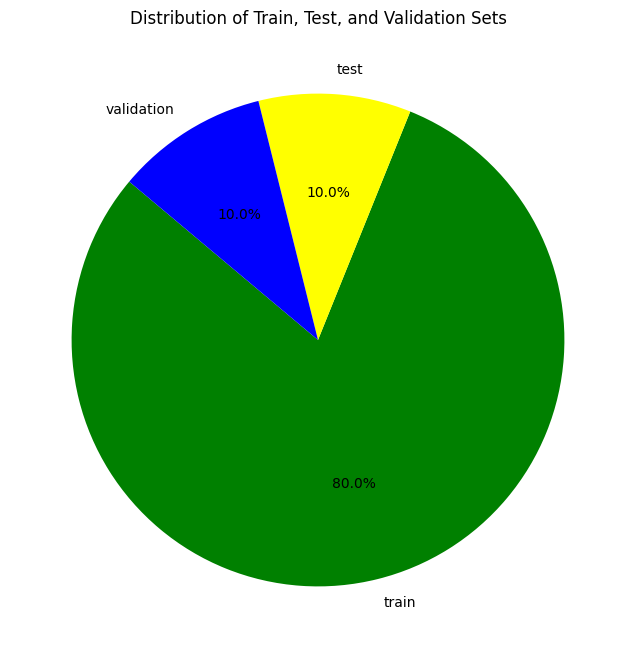

In [25]:
import matplotlib.pyplot as plt

# Assuming 'Split' contains categories like 'train', 'test', and 'validation'
split_counts = data['Split'].value_counts()

# Pie chart
plt.figure(figsize=(8, 8))
plt.pie(split_counts.values, labels=split_counts.index, autopct='%1.1f%%', colors=['green', 'yellow', 'blue'], startangle=140)
plt.title('Distribution of Train, Test, and Validation Sets')
plt.show()


array([[[36, 36, 36],
        [36, 36, 36],
        [35, 35, 35],
        ...,
        [28, 28, 28],
        [19, 19, 19],
        [12, 12, 12]],

       [[30, 30, 30],
        [30, 30, 30],
        [31, 31, 31],
        ...,
        [26, 26, 26],
        [17, 17, 17],
        [ 9,  9,  9]],

       [[26, 26, 26],
        [27, 27, 27],
        [30, 30, 30],
        ...,
        [25, 25, 25],
        [16, 16, 16],
        [ 8,  8,  8]],

       ...,

       [[24, 24, 24],
        [23, 23, 23],
        [23, 23, 23],
        ...,
        [25, 25, 25],
        [18, 18, 18],
        [12, 12, 12]],

       [[11, 11, 11],
        [11, 11, 11],
        [11, 11, 11],
        ...,
        [19, 19, 19],
        [14, 14, 14],
        [10, 10, 10]],

       [[ 6,  6,  6],
        [ 6,  6,  6],
        [ 6,  6,  6],
        ...,
        [15, 15, 15],
        [10, 10, 10],
        [ 6,  6,  6]]], dtype=uint8)
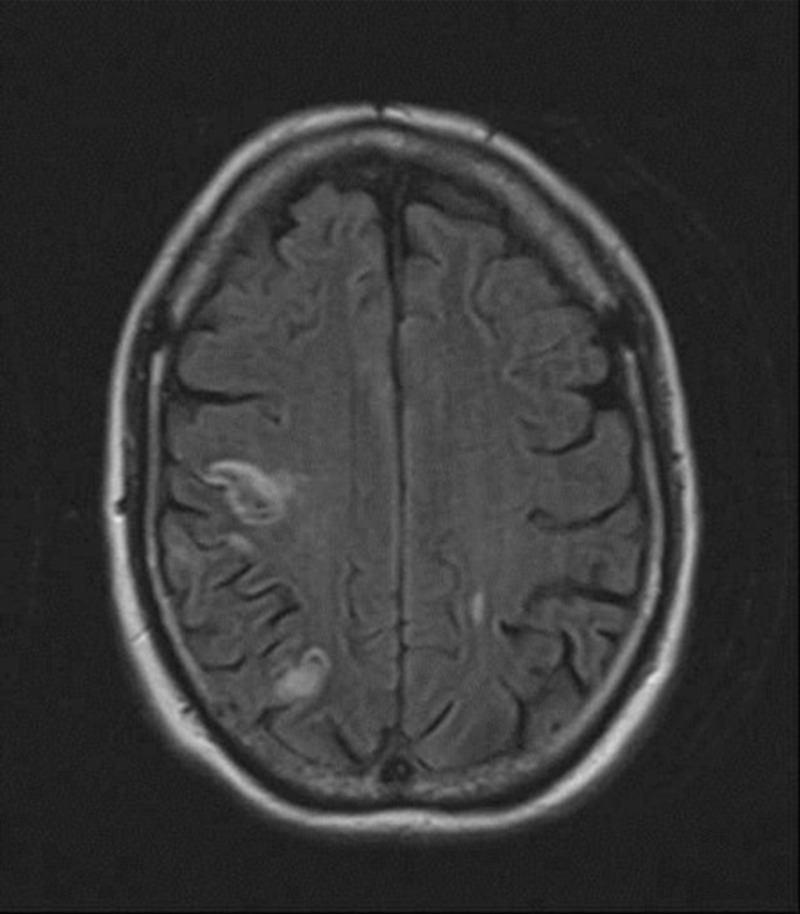

In [28]:
import cv2
img_dir = "/content/drive/MyDrive/ROCO/data/train/radiology/images"

image_files=[f for f in os.listdir(img_dir) if f.endswith(".jpg")]

img_path=os.path.join(img_dir,image_files[200])

img=cv2.imread(img_path)
img



(914, 800, 3)


array([[[29, 29, 29],
        [33, 33, 33],
        [30, 30, 30],
        ...,
        [34, 34, 34],
        [30, 30, 30],
        [19, 19, 19]],

       [[29, 29, 29],
        [30, 30, 30],
        [32, 32, 32],
        ...,
        [32, 32, 32],
        [28, 28, 28],
        [15, 15, 15]],

       [[30, 30, 30],
        [34, 34, 34],
        [28, 28, 28],
        ...,
        [34, 34, 34],
        [30, 30, 30],
        [20, 20, 20]],

       ...,

       [[32, 32, 32],
        [32, 32, 32],
        [30, 30, 30],
        ...,
        [34, 34, 34],
        [32, 32, 32],
        [19, 19, 19]],

       [[30, 30, 30],
        [28, 28, 28],
        [30, 30, 30],
        ...,
        [28, 28, 28],
        [29, 29, 29],
        [18, 18, 18]],

       [[17, 17, 17],
        [17, 17, 17],
        [19, 19, 19],
        ...,
        [17, 17, 17],
        [17, 17, 17],
        [17, 17, 17]]], dtype=uint8)
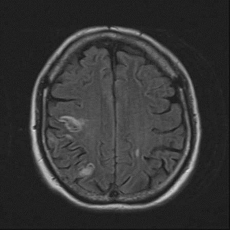

In [29]:
print(img.shape)
target_size=(230,230)
cv2.resize(img,target_size)

array([[36, 36, 35, ..., 28, 19, 12],
       [30, 30, 31, ..., 26, 17,  9],
       [26, 27, 30, ..., 25, 16,  8],
       ...,
       [24, 23, 23, ..., 25, 18, 12],
       [11, 11, 11, ..., 19, 14, 10],
       [ 6,  6,  6, ..., 15, 10,  6]], dtype=uint8)
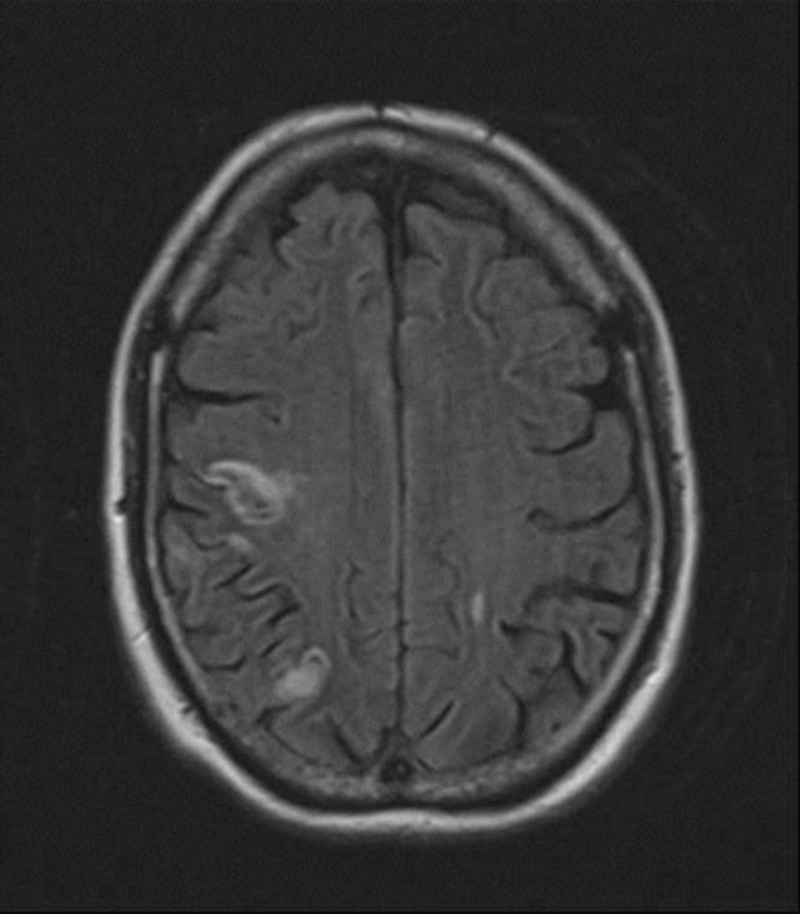

In [30]:
img_processed=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
img_processed


In [31]:

imgnormalised=img/255
imgnormalised

array([[[0.14117647, 0.14117647, 0.14117647],
        [0.14117647, 0.14117647, 0.14117647],
        [0.1372549 , 0.1372549 , 0.1372549 ],
        ...,
        [0.10980392, 0.10980392, 0.10980392],
        [0.0745098 , 0.0745098 , 0.0745098 ],
        [0.04705882, 0.04705882, 0.04705882]],

       [[0.11764706, 0.11764706, 0.11764706],
        [0.11764706, 0.11764706, 0.11764706],
        [0.12156863, 0.12156863, 0.12156863],
        ...,
        [0.10196078, 0.10196078, 0.10196078],
        [0.06666667, 0.06666667, 0.06666667],
        [0.03529412, 0.03529412, 0.03529412]],

       [[0.10196078, 0.10196078, 0.10196078],
        [0.10588235, 0.10588235, 0.10588235],
        [0.11764706, 0.11764706, 0.11764706],
        ...,
        [0.09803922, 0.09803922, 0.09803922],
        [0.0627451 , 0.0627451 , 0.0627451 ],
        [0.03137255, 0.03137255, 0.03137255]],

       ...,

       [[0.09411765, 0.09411765, 0.09411765],
        [0.09019608, 0.09019608, 0.09019608],
        [0.09019608, 0

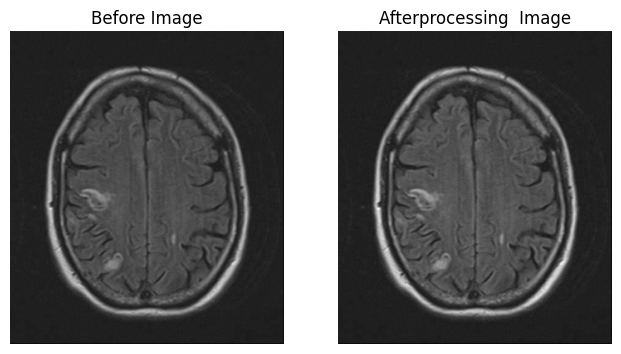

In [34]:

plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(1, 3, 1)
img_original = cv2.imread(img_path)
plt.imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB))
plt.title('Before Image')
plt.axis('off')

# Processed Image (Grayscale & Normalized)
plt.subplot(1, 3, 2)
plt.imshow(img_processed.squeeze(), cmap='gray')
plt.title('Afterprocessing  Image')
plt.axis('off')



plt.show()


#Augmentation